   age  gender  sleep_quality_index  brain_fog_level  physical_pain_score  \
0   56    Male                  8.7              3.9                  9.2   
1   69    Male                  1.3              9.9                  4.2   
2   46  Female                  4.0              5.4                  4.8   
3   32  Female                  9.4              2.1                  2.9   
4   60  Female                  7.6              7.5                  6.4   

   stress_level  depression_phq9_score  fatigue_severity_scale_score  \
0           8.1                   10.0                           6.5   
1           9.9                   20.0                           7.0   
2           NaN                   24.0                           1.6   
3           3.8                   10.0                           6.8   
4           8.5                   17.0                           7.0   

   pem_duration_hours  hours_of_sleep_per_night  pem_present  \
0                 9.0                   

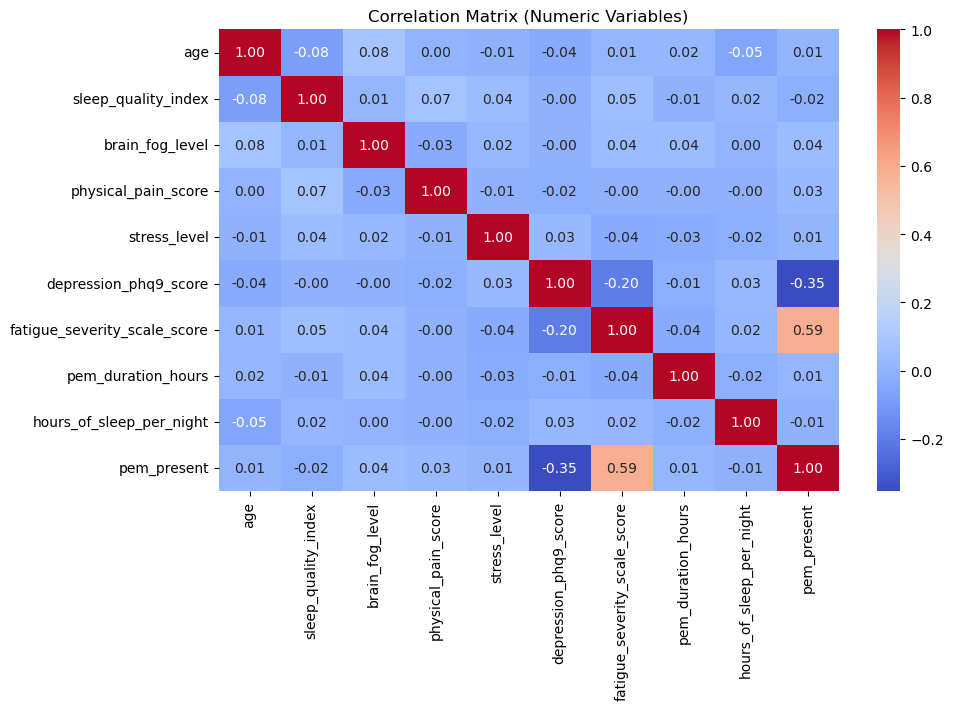

0


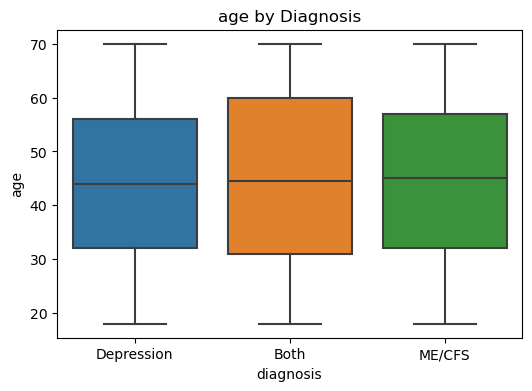

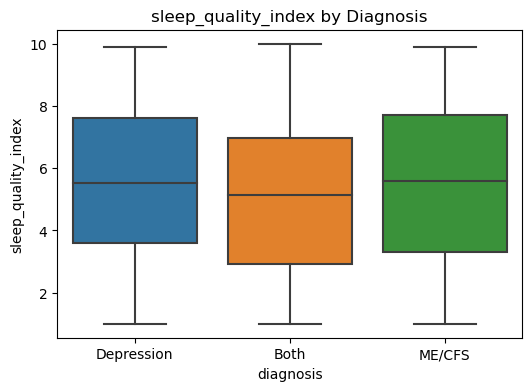

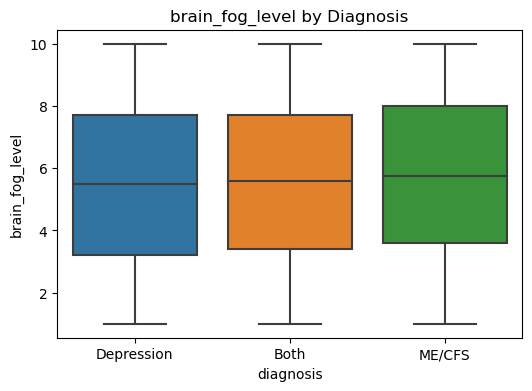

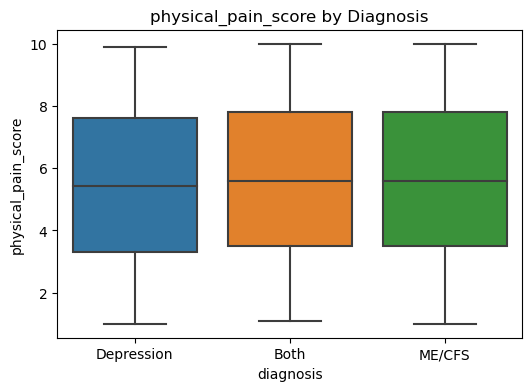

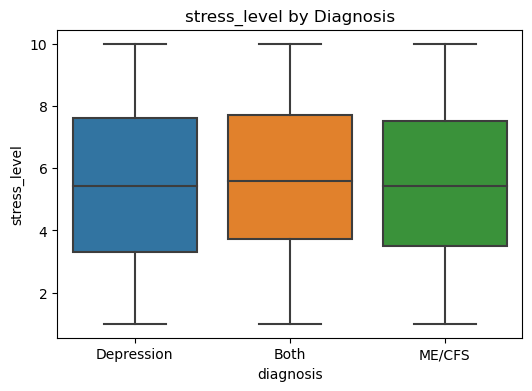


KeyboardInterrupt



<Figure size 600x400 with 0 Axes>

In [2]:
import pandas as pd
import os

# === Paths ===
base_path = os.path.expanduser("~/Desktop/ProjectME")
data_path = os.path.join(base_path, "datasets", "2.me_cfs_vs_depression_dataset.csv")

# Replace the path with where your CSV is stored
df = pd.read_csv(data_path)


# Quick look at the first rows
print(df.head())

# Check basic info
print(df.info())


# Check missing value distribution to see how we handle that
df.isnull().sum().sort_values(ascending=False)

# Less than 5% values missing so we do imputation, however I'll use domain knowledge to impute missing value in a given jXi based on a function F(X) instead of using just the mean
# For example, PEM values could be correlated with pain scores and sleep quality by defintion
# Let's first explore this correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_df = df.select_dtypes(include='number')

# Correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Variables)")
plt.show()

## Findings:
# Surprisingly no correlation between age and any of the other variables, you'd think that old people would complain more, similarly no connection between sleep hours and pem duration
# Strong correlation between fatigue levels and peak PEM hours 0.6
# Some correlation between depression scores and PEM/fatigue 39%/20% respectively, Pem must be really depressing..


# Imputation based on findings
# 1D imputation for fatigue scales and pem hours
df['fatigue_severity_scale_score'] = df.groupby('diagnosis')['fatigue_severity_scale_score'].transform(lambda x: x.fillna(x.mean()))
df['pem_duration_hours'] = df.groupby('diagnosis')['pem_duration_hours'].transform(lambda x: x.fillna(x.mean()))
# 2D imputation for depression
df['depression_phq9_score'] = df.groupby(['diagnosis', pd.qcut(df['fatigue_severity_scale_score'], q=4)])['depression_phq9_score'].transform(lambda x: x.fillna(x.mean()))


# Imputing everything else missing by mean, grouped first by diagnosis
# Numeric columns to impute (symptom-related)
num_grouped = [
    'fatigue_severity_scale_score', 'pem_duration_hours', 
    'brain_fog_level', 'stress_level', 'physical_pain_score', 
    'sleep_quality_index'
]

# Depression score: impute based on diagnosis + fatigue quartiles
df['fatigue_quartile'] = pd.qcut(df['fatigue_severity_scale_score'].fillna(df['fatigue_severity_scale_score'].mean()), 4)

df['depression_phq9_score'] = df.groupby(['diagnosis', 'fatigue_quartile'])['depression_phq9_score'].transform(lambda x: x.fillna(x.mean()))

# Impute symptom-related numeric columns by diagnosis
for col in num_grouped:
    df[col] = df.groupby('diagnosis')[col].transform(lambda x: x.fillna(x.mean()))

# Sleep hours: impute by diagnosis
df['hours_of_sleep_per_night'] = df.groupby('diagnosis')['hours_of_sleep_per_night'].transform(lambda x: x.fillna(x.mean()))

# Categorical columns to impute
cat_cols = ['work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness']

for col in cat_cols:
    df[col] = df.groupby('diagnosis')[col].transform(lambda x: x.fillna(x.mode()[0]))

# Drop helper column
df.drop(columns='fatigue_quartile', inplace=True)

# Verify no missing values remain
print(df.isnull().sum().sum()) 

# No missing values left, good

# Lets look at distribution plots now and expolre diagnosis vs feature correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Example 1: Numeric vs Diagnosis
num_cols = df.select_dtypes(include='number').columns.drop('pem_present')  # ignore binary
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'{col} by Diagnosis')
    plt.show()

# Example 2: Numeric vs Gender
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='gender', y=col, data=df)
    plt.title(f'{col} by Gender')
    plt.show()

# Example 3: Numeric vs Categorical features (like work_status)
cat_features = ['work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness']
for cat in cat_features:
    for col in num_cols:
        plt.figure(figsize=(8,4))
        sns.boxplot(x=cat, y=col, data=df)
        plt.title(f'{col} by {cat}')
        plt.xticks(rotation=45)
        plt.show()
        
        
## FINDINGS:
# mainly, the differentiating factor between people with Depression vs people with MECFS is the reported fatigue and PEM hours, although some people with ME are depressed, others are not and are still very fatigued, this indicated that the two conditions are certainly distinct
# Infact, some people with ME reported very low depression levels 
# More outliers in fatigue severty amongst the people who exerciced daily and very often compared to those who exerciced rarely or never
# Exercice seems to be either helping emmensly in some cases while being very bad in others, maybe we should test statistical significance of this 
# overall stability of fatigue severity (high) in people who never or rarely exercice
# Longer lasting pem in some cases of people who exercice daily, though the whole IQR is wider, again this is way more stable and slightly lower in people who never exercice
# Funnily enough meditation seems to have improved everyone's sleep time by a few minutes as well as lowered their depression levels very very slightly
# Females reported less fatigue severity in comparisson with males
# All else seems to be equal and no further strong findings 


# Next:
# let's look at how fatigue impacts exercice in people labeled with cfs, and not depression
# and how it impacts thier work

# Filter for ME/CFS only
cfs = df[df['diagnosis'] == 'ME/CFS']

# Fatigue vs Exercise Frequency (ME/CFS)
sns.violinplot(x='exercise_frequency', y='fatigue_severity_scale_score', data=cfs, inner='quartile', palette='coolwarm')
plt.title('Fatigue Severity vs Exercise Frequency (ME/CFS)')
plt.xticks(rotation=45)
plt.show()

# Fatigue vs Work Status (ME/CFS)
sns.violinplot(x='work_status', y='fatigue_severity_scale_score', data=cfs, inner='quartile', palette='viridis')
plt.title('Fatigue Severity vs Work Status (ME/CFS)')
plt.xticks(rotation=45)
plt.show()


   age  gender  sleep_quality_index  brain_fog_level  physical_pain_score  \
0   56    Male                  8.7              3.9                  9.2   
1   69    Male                  1.3              9.9                  4.2   
2   46  Female                  4.0              5.4                  4.8   
3   32  Female                  9.4              2.1                  2.9   
4   60  Female                  7.6              7.5                  6.4   

   stress_level  depression_phq9_score  fatigue_severity_scale_score  \
0           8.1                   10.0                           6.5   
1           9.9                   20.0                           7.0   
2           NaN                   24.0                           1.6   
3           3.8                   10.0                           6.8   
4           8.5                   17.0                           7.0   

   pem_duration_hours  hours_of_sleep_per_night  pem_present  \
0                 9.0                   

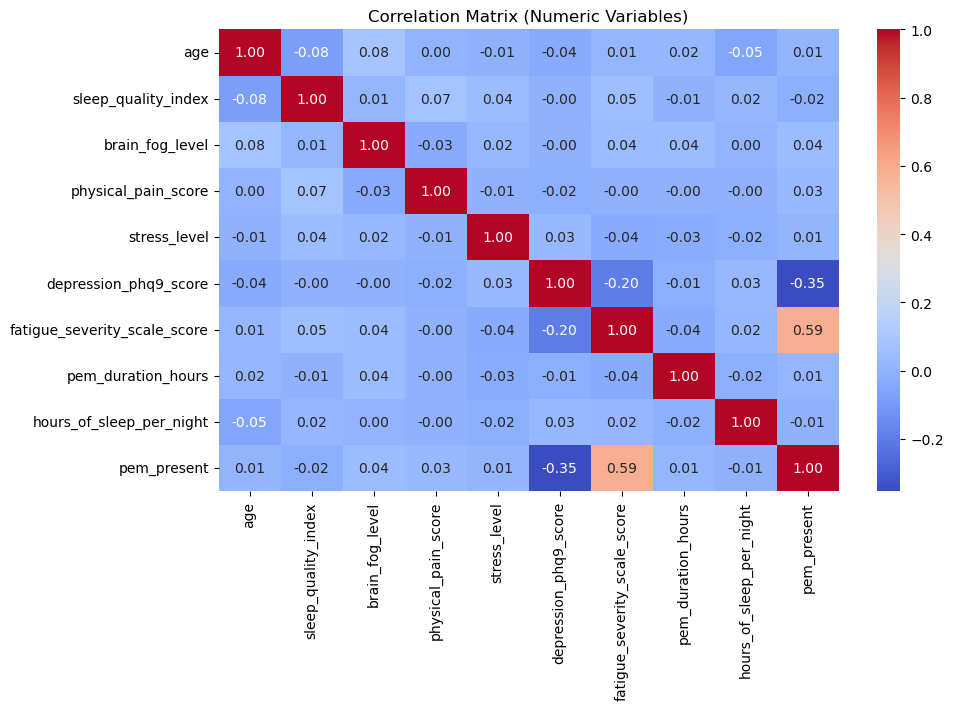

0


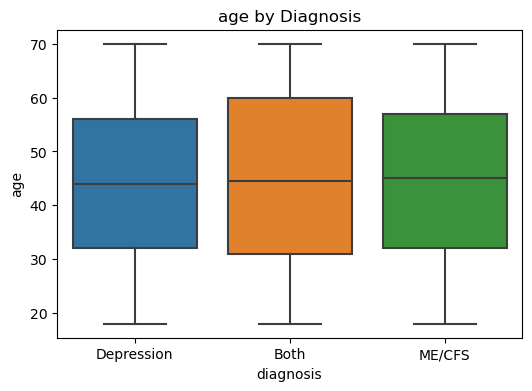

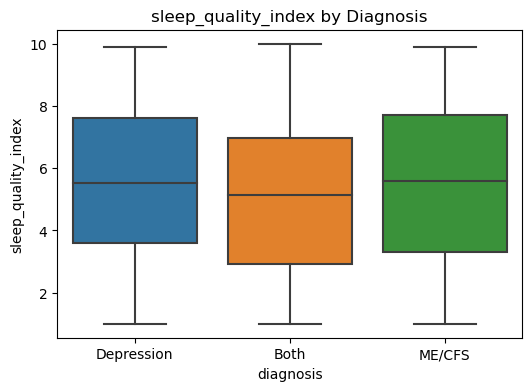

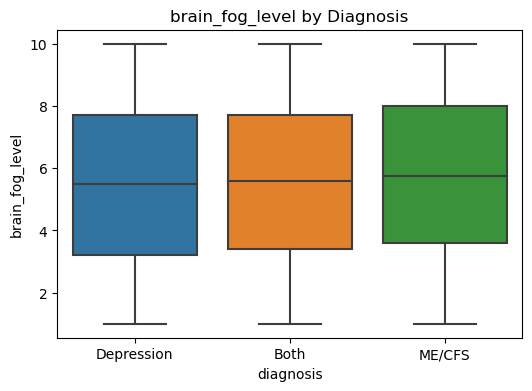

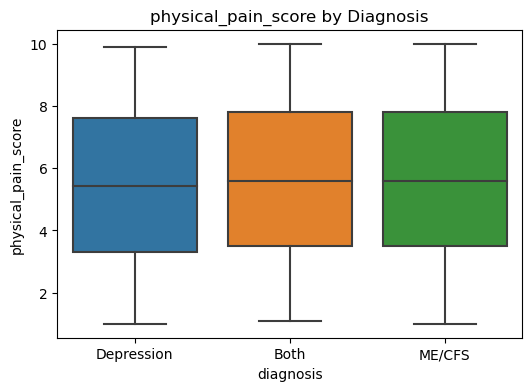

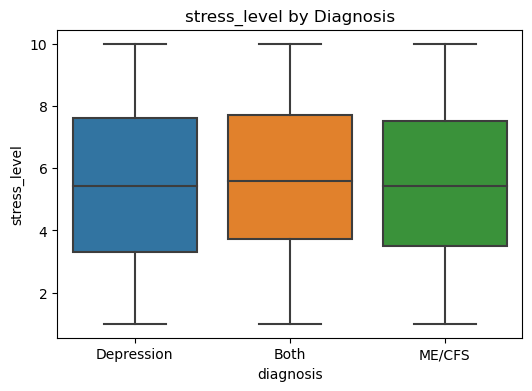

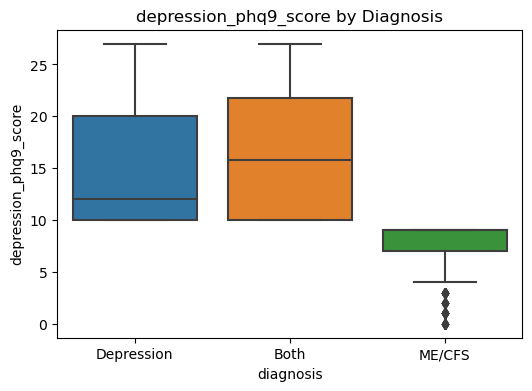

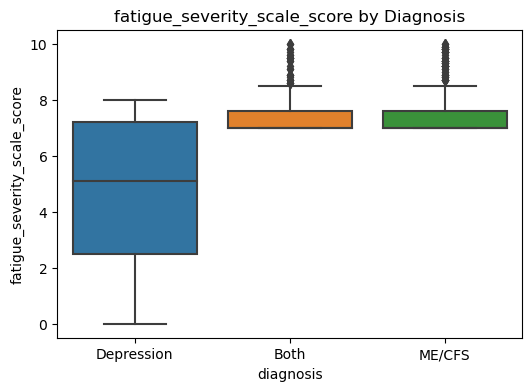

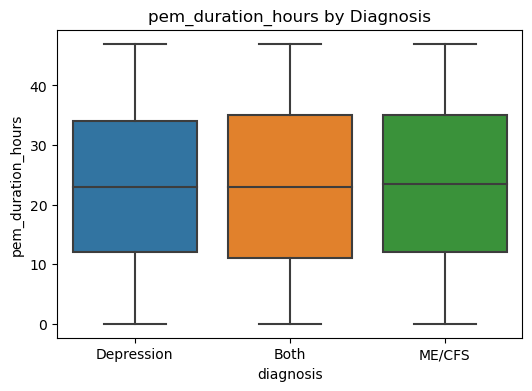

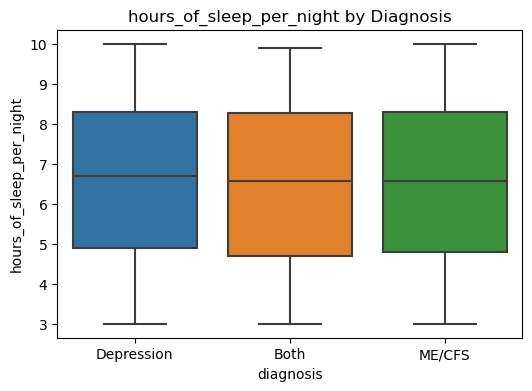

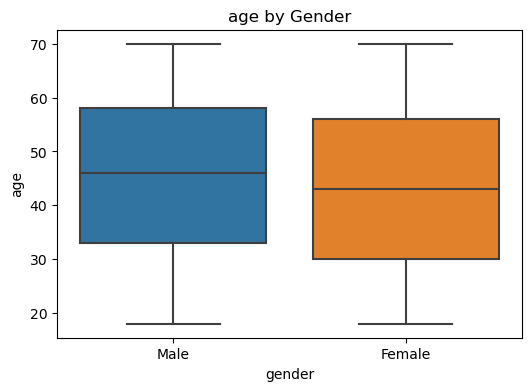

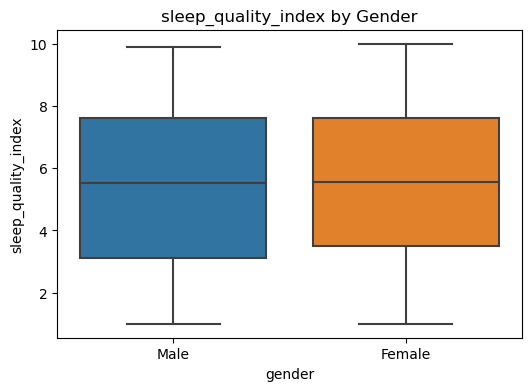

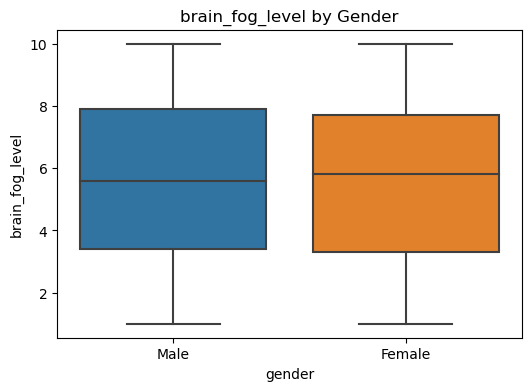

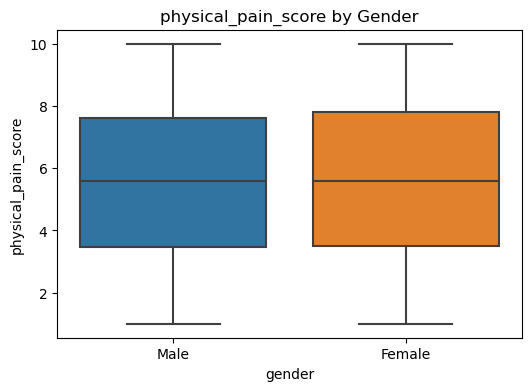

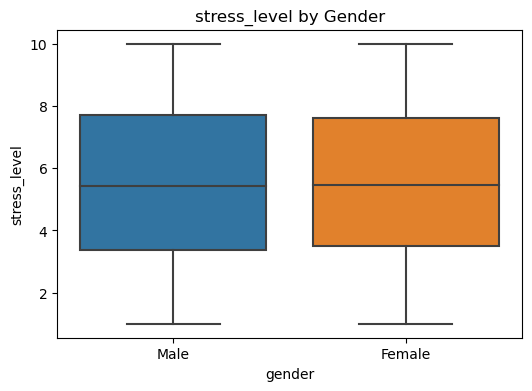

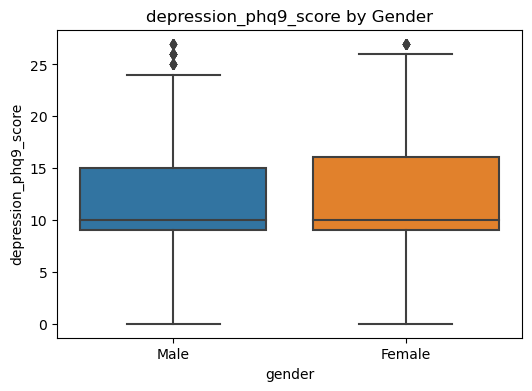

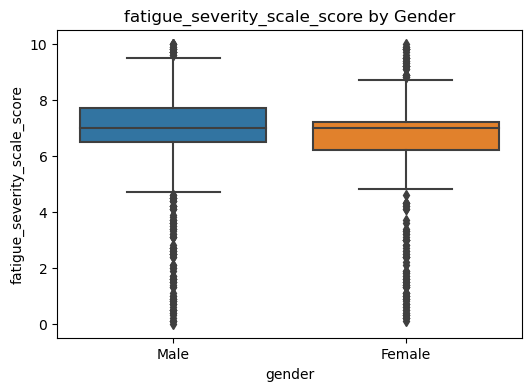

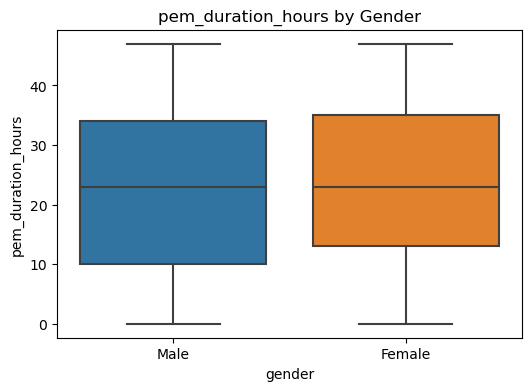

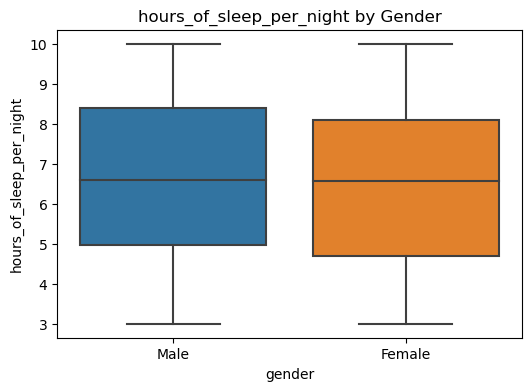

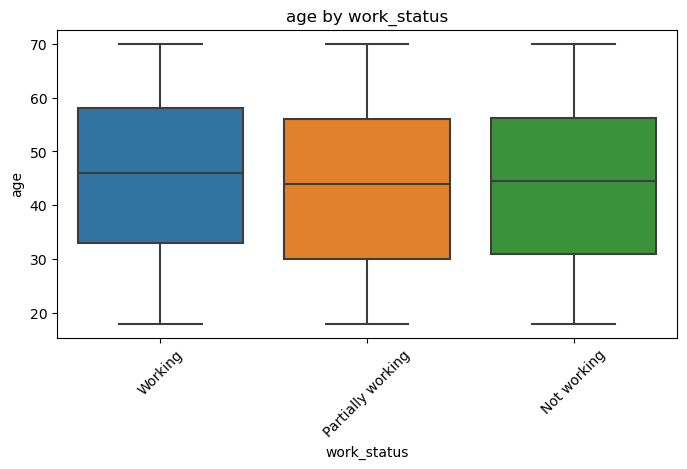

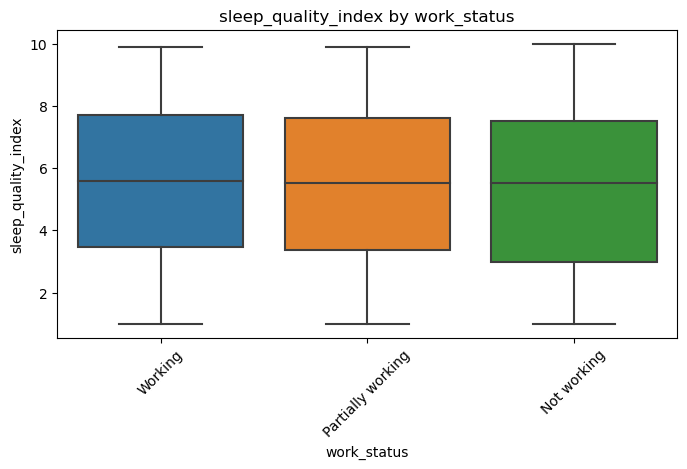

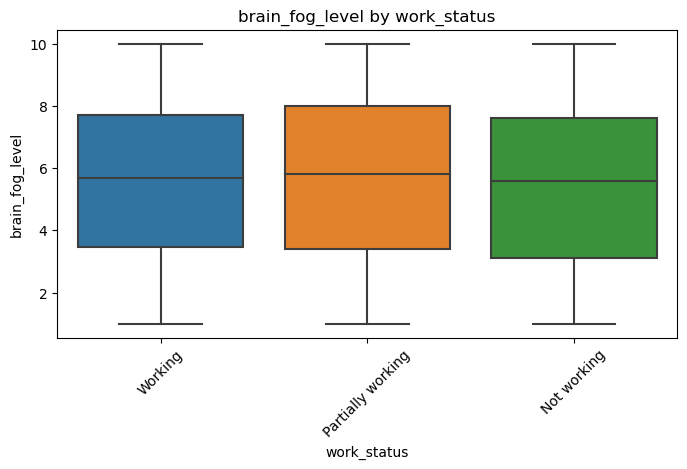

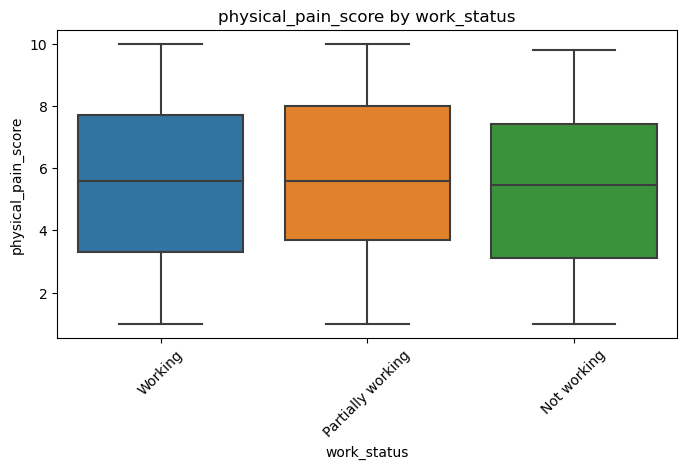

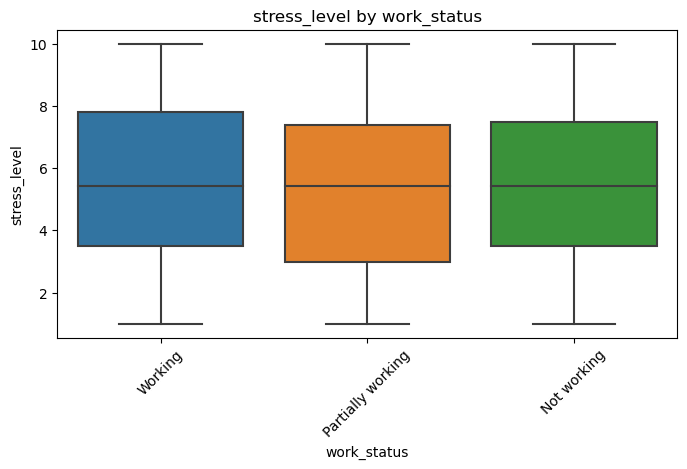

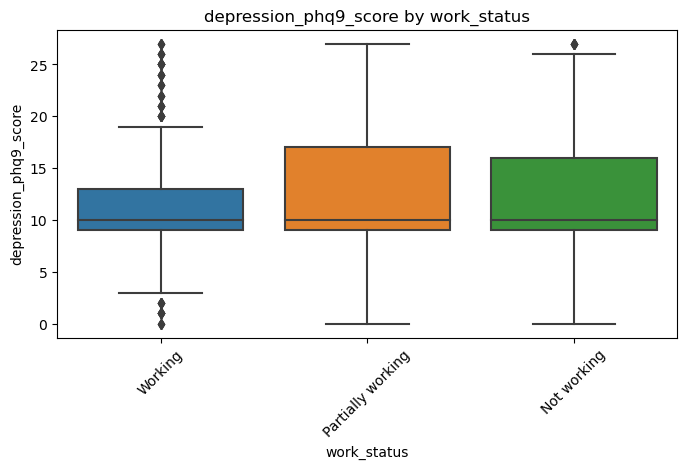

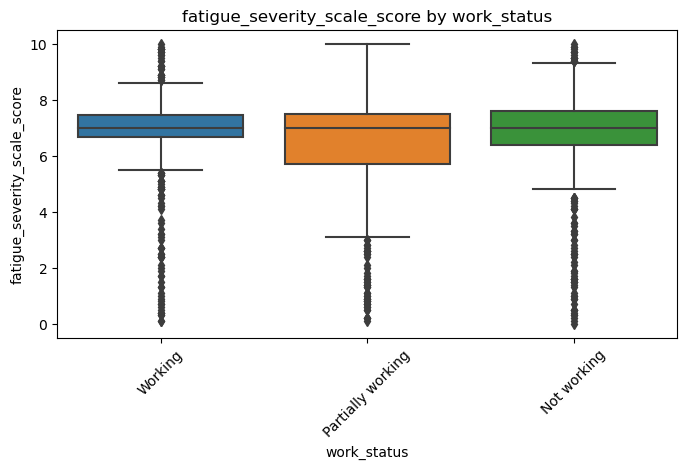

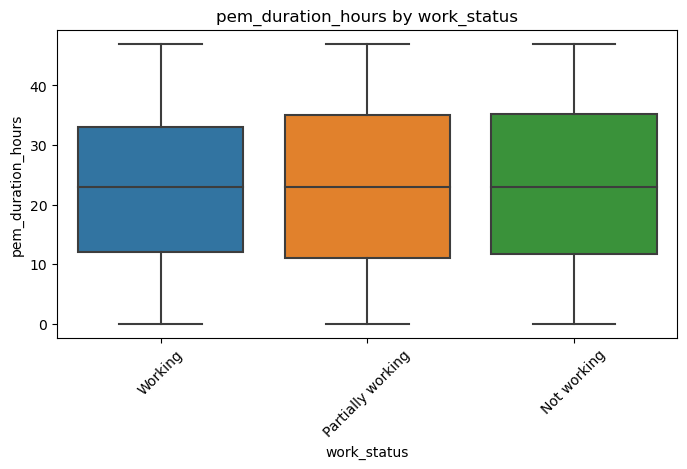

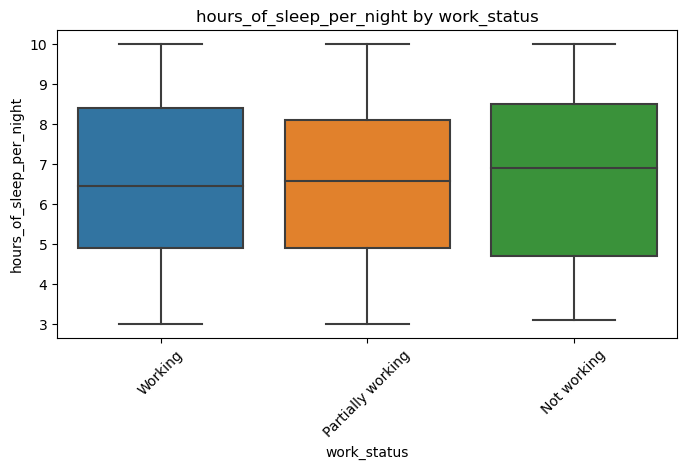

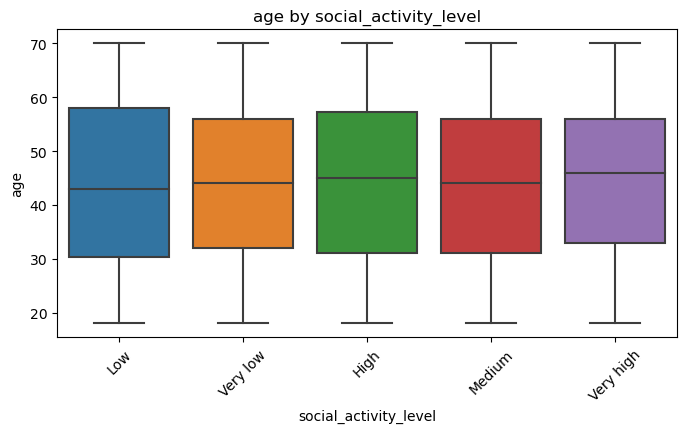

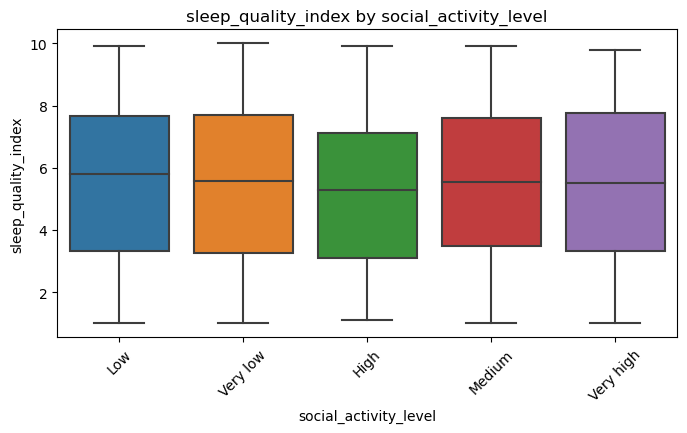

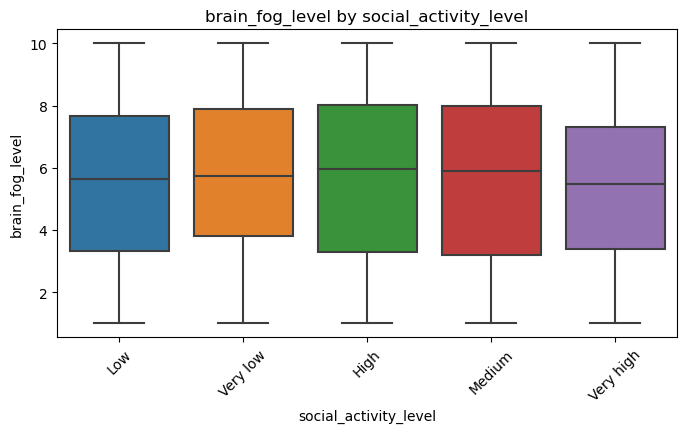

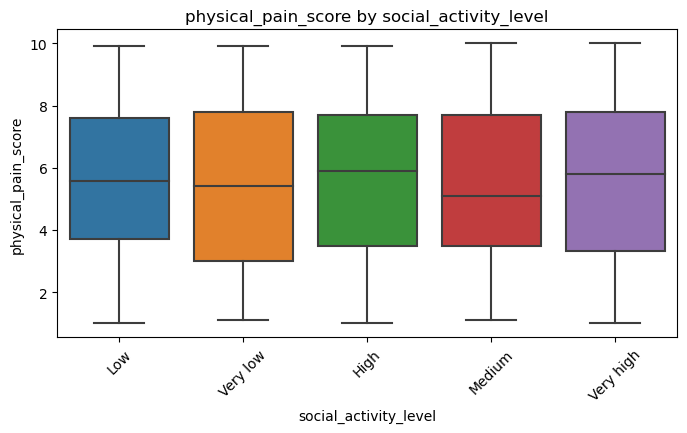

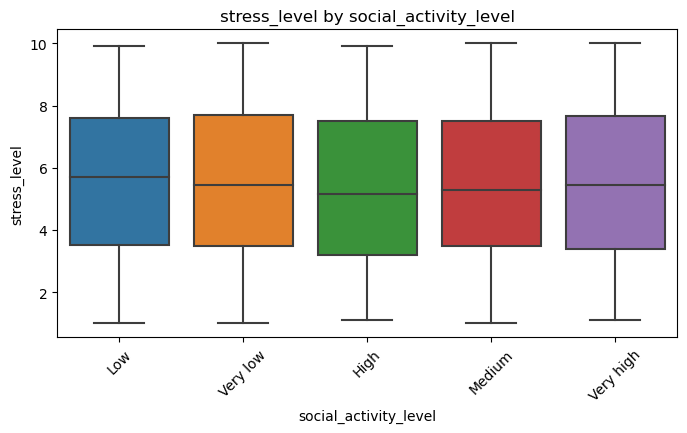

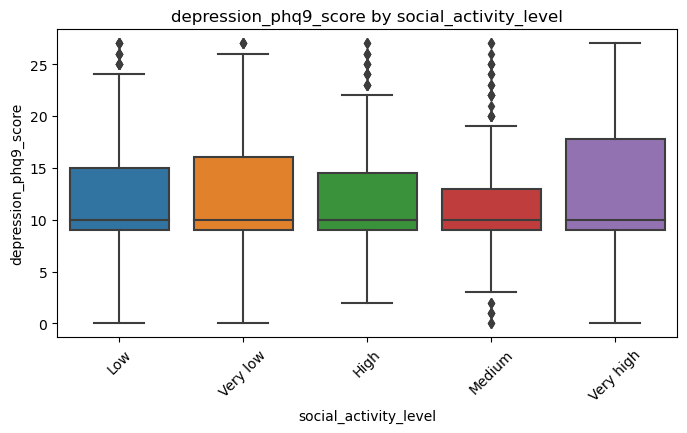

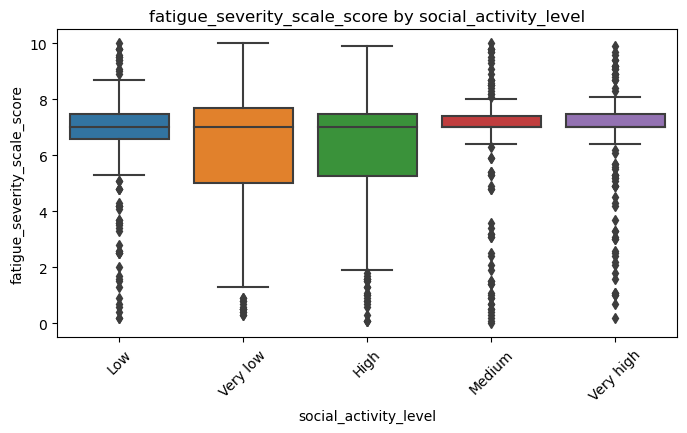

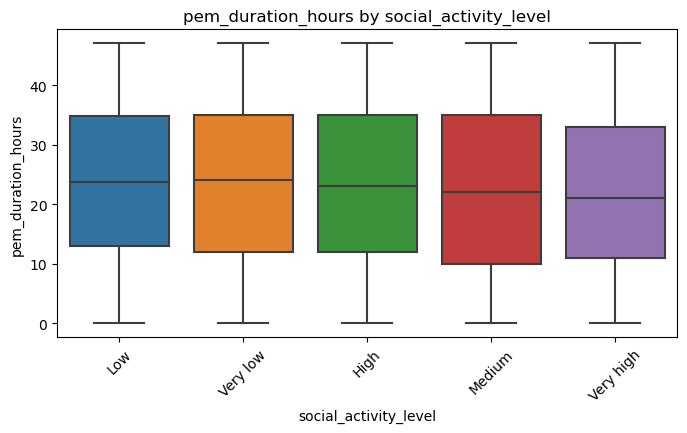

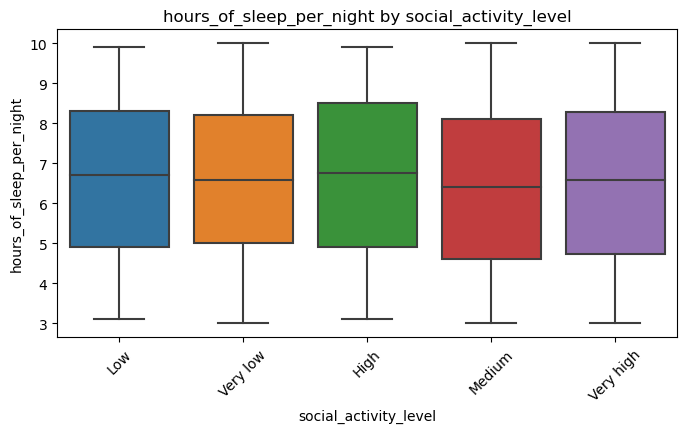

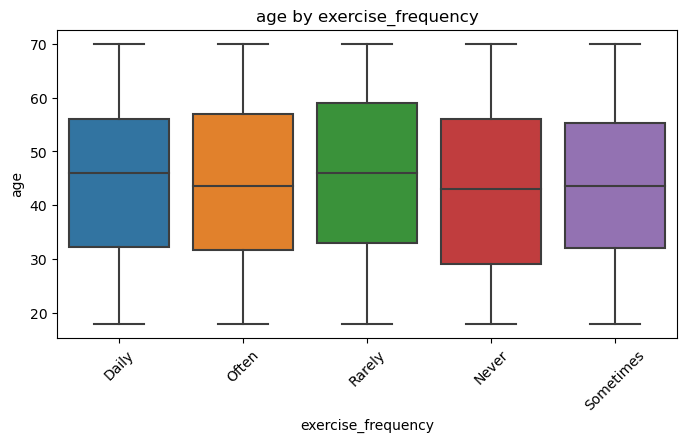

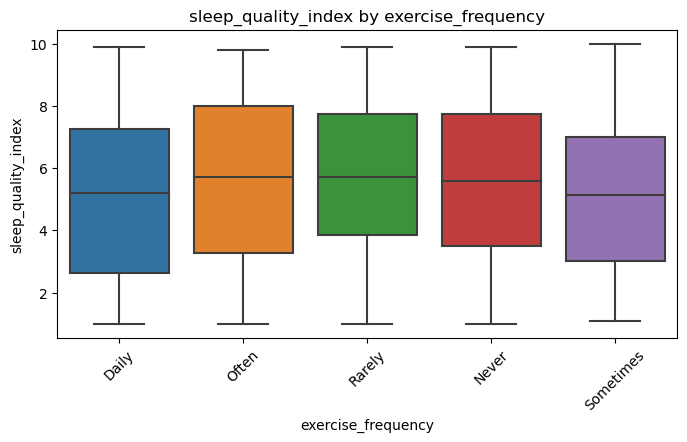

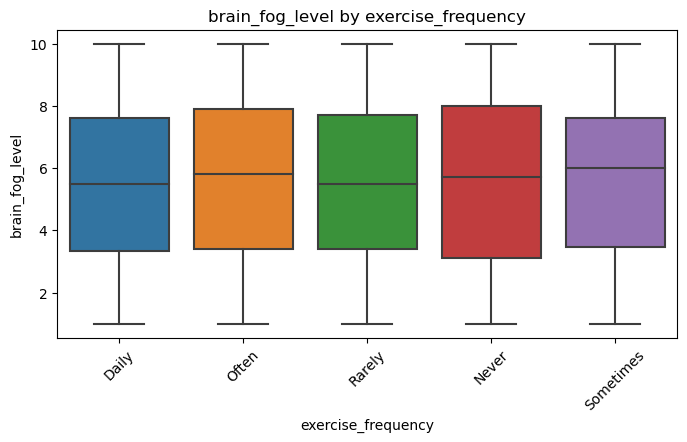

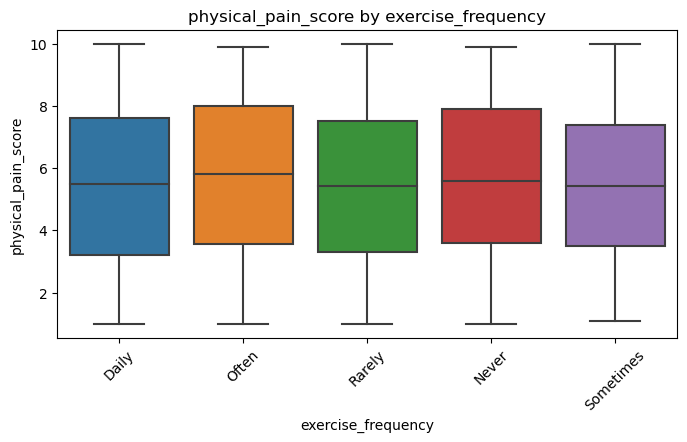

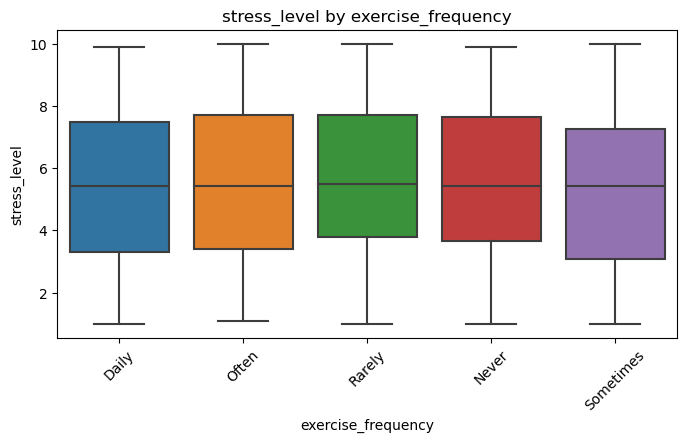

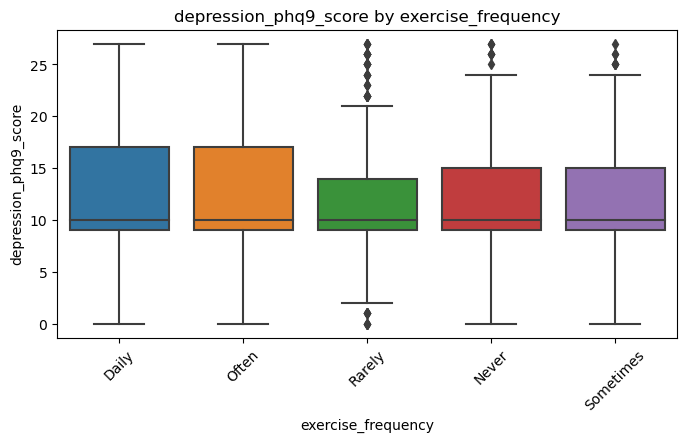

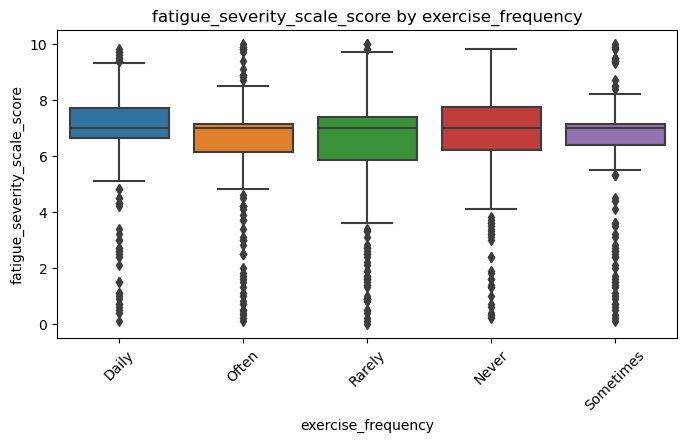

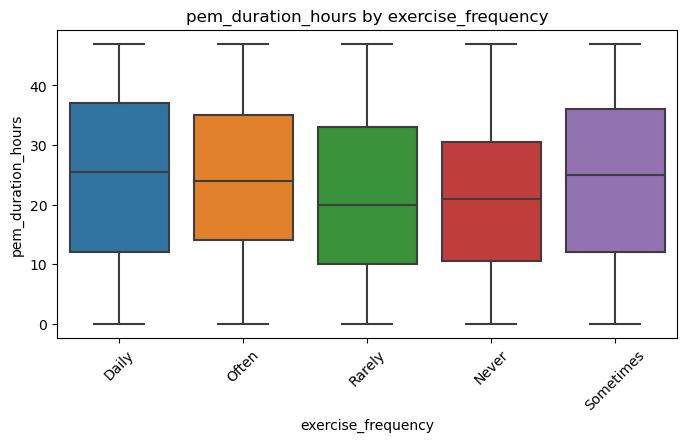

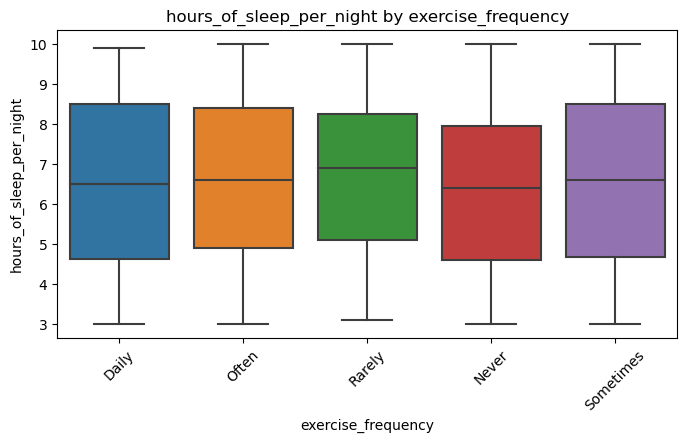

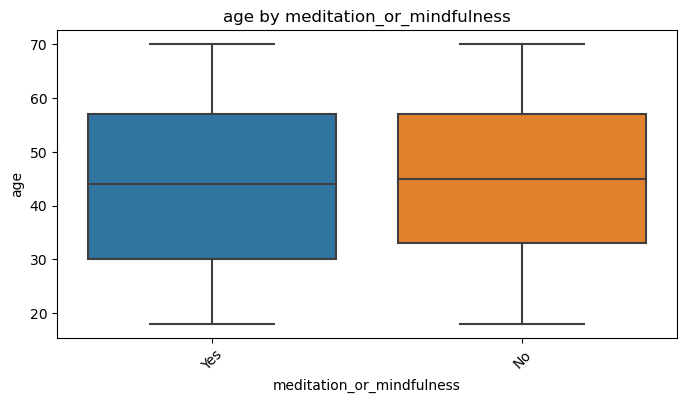

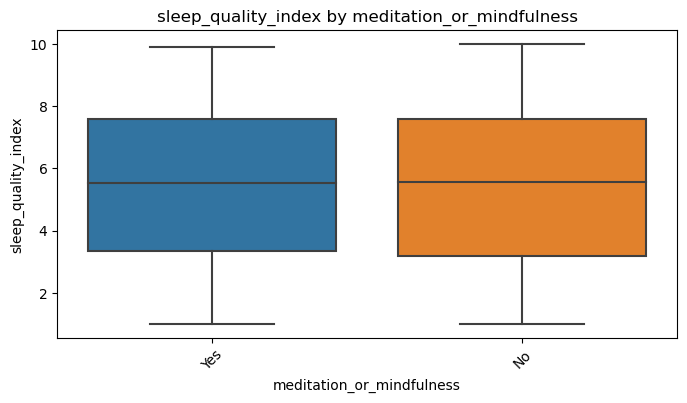

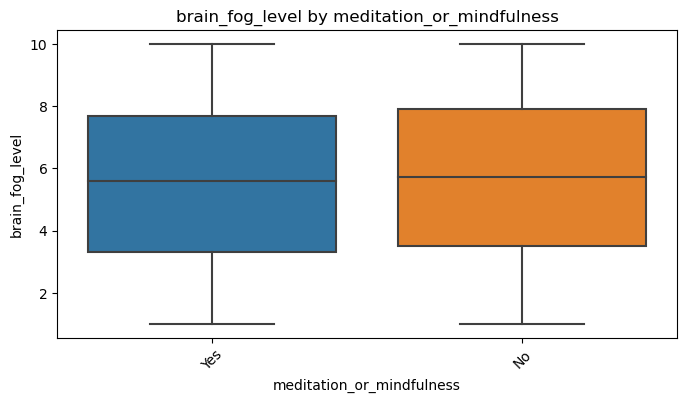

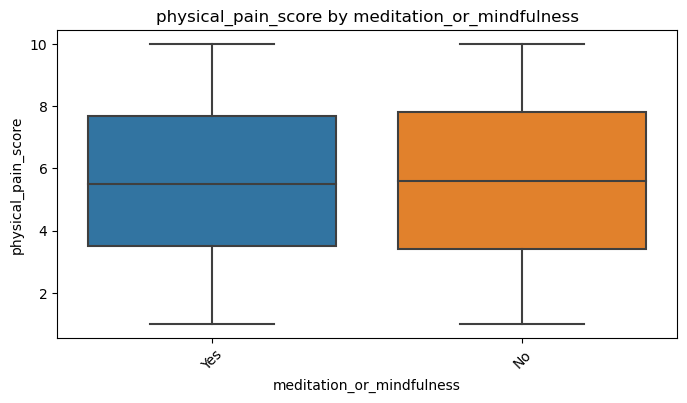

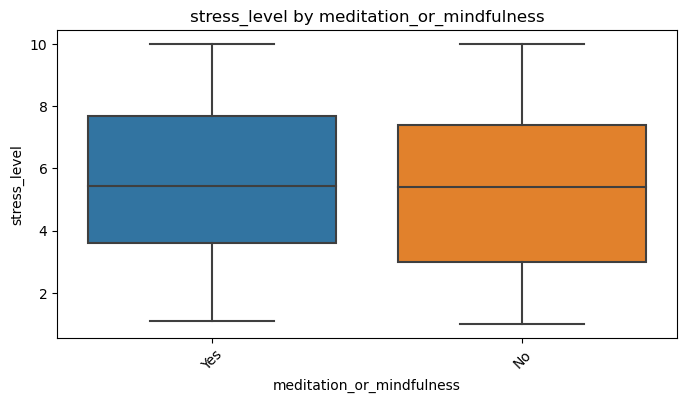

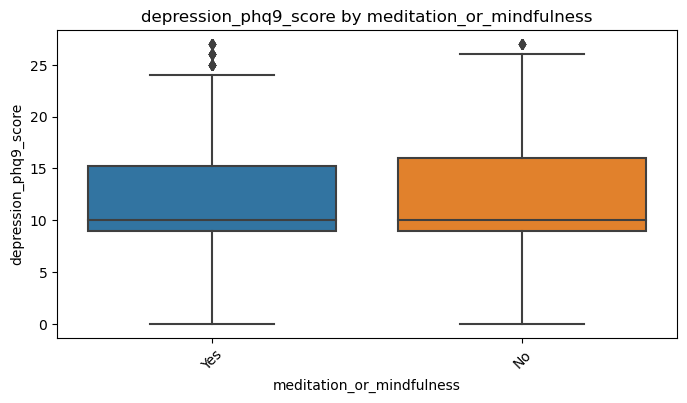

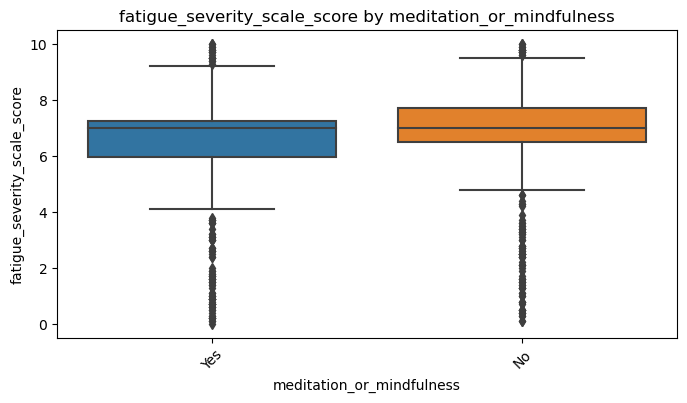

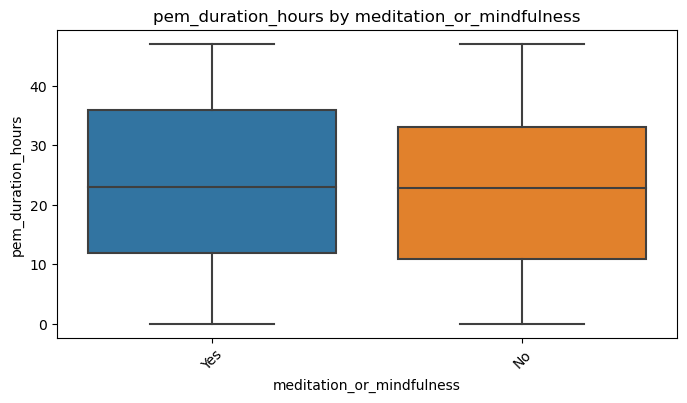

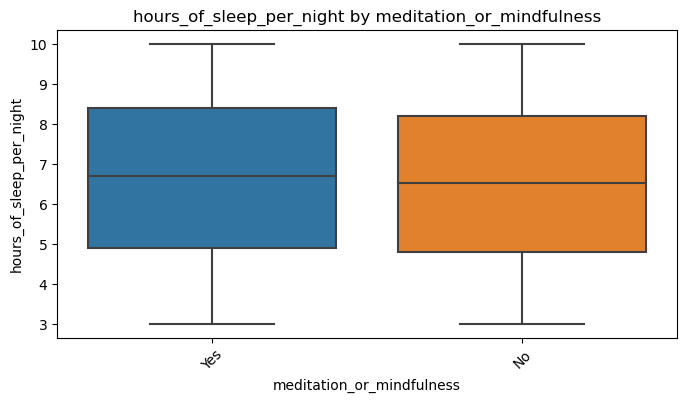

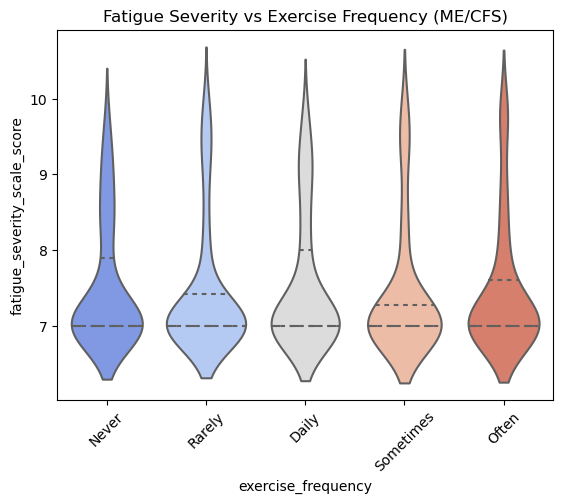

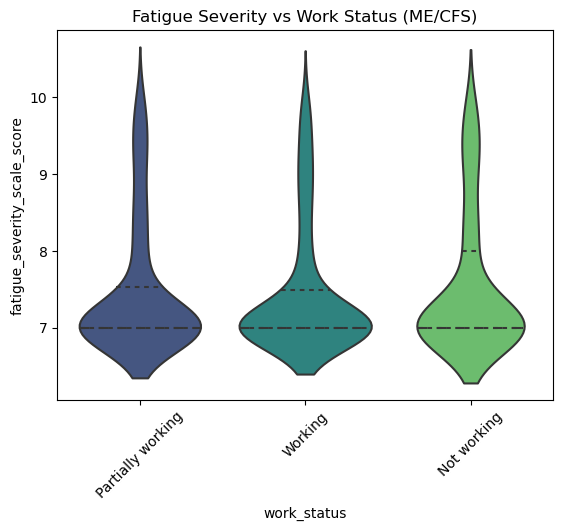

In [21]:
import pandas as pd
import os

# === Paths ===
base_path = os.path.expanduser("~/Desktop/ProjectME")
data_path = os.path.join(base_path, "datasets", "2.me_cfs_vs_depression_dataset.csv")

# Replace the path with where your CSV is stored
df = pd.read_csv(data_path)


# Quick look at the first rows
print(df.head())

# Check basic info
print(df.info())


# Check missing value distribution to see how we handle that
df.isnull().sum().sort_values(ascending=False)

# Less than 5% values missing so we do imputation, however I'll use domain knowledge to impute missing value in a given jXi based on a function F(X) instead of using just the mean
# For example, PEM values could be correlated with pain scores and sleep quality by defintion
# Let's first explore this correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_df = df.select_dtypes(include='number')

# Correlation matrix
corr = num_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Variables)")
plt.show()

## Findings:
# Surprisingly no correlation between age and any of the other variables, you'd think that old people would complain more, similarly no connection between sleep hours and pem duration
# Strong correlation between fatigue levels and peak PEM hours 0.6
# Some correlation between depression scores and PEM/fatigue 39%/20% respectively, Pem must be really depressing..


# Imputation based on findings
# 1D imputation for fatigue scales and pem hours
df['fatigue_severity_scale_score'] = df.groupby('diagnosis')['fatigue_severity_scale_score'].transform(lambda x: x.fillna(x.mean()))
df['pem_duration_hours'] = df.groupby('diagnosis')['pem_duration_hours'].transform(lambda x: x.fillna(x.mean()))
# 2D imputation for depression
df['depression_phq9_score'] = df.groupby(['diagnosis', pd.qcut(df['fatigue_severity_scale_score'], q=4)])['depression_phq9_score'].transform(lambda x: x.fillna(x.mean()))


# Imputing everything else missing by mean, grouped first by diagnosis
# Numeric columns to impute (symptom-related)
num_grouped = [
    'fatigue_severity_scale_score', 'pem_duration_hours', 
    'brain_fog_level', 'stress_level', 'physical_pain_score', 
    'sleep_quality_index'
]

# Depression score: impute based on diagnosis + fatigue quartiles
df['fatigue_quartile'] = pd.qcut(df['fatigue_severity_scale_score'].fillna(df['fatigue_severity_scale_score'].mean()), 4)

df['depression_phq9_score'] = df.groupby(['diagnosis', 'fatigue_quartile'])['depression_phq9_score'].transform(lambda x: x.fillna(x.mean()))

# Impute symptom-related numeric columns by diagnosis
for col in num_grouped:
    df[col] = df.groupby('diagnosis')[col].transform(lambda x: x.fillna(x.mean()))

# Sleep hours: impute by diagnosis
df['hours_of_sleep_per_night'] = df.groupby('diagnosis')['hours_of_sleep_per_night'].transform(lambda x: x.fillna(x.mean()))

# Categorical columns to impute
cat_cols = ['work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness']

for col in cat_cols:
    df[col] = df.groupby('diagnosis')[col].transform(lambda x: x.fillna(x.mode()[0]))

# Drop helper column
df.drop(columns='fatigue_quartile', inplace=True)

# Verify no missing values remain
print(df.isnull().sum().sum()) 

# No missing values left, good

# Lets look at distribution plots now and expolre diagnosis vs feature correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Example 1: Numeric vs Diagnosis
num_cols = df.select_dtypes(include='number').columns.drop('pem_present')  # ignore binary
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'{col} by Diagnosis')
    plt.show()

# Example 2: Numeric vs Gender
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='gender', y=col, data=df)
    plt.title(f'{col} by Gender')
    plt.show()

# Example 3: Numeric vs Categorical features (like work_status)
cat_features = ['work_status', 'social_activity_level', 'exercise_frequency', 'meditation_or_mindfulness']
for cat in cat_features:
    for col in num_cols:
        plt.figure(figsize=(8,4))
        sns.boxplot(x=cat, y=col, data=df)
        plt.title(f'{col} by {cat}')
        plt.xticks(rotation=45)
        plt.show()
        
        
## FINDINGS:
# mainly, the differentiating factor between people with Depression vs people with MECFS is the reported fatigue and PEM hours, although some people with ME are depressed, others are not and are still very fatigued, this indicated that the two conditions are certainly distinct
# Infact, some people with ME reported very low depression levels 
# More outliers in fatigue severty amongst the people who exerciced daily and very often compared to those who exerciced rarely or never
# Exercice seems to be either helping emmensly in some cases while being very bad in others, maybe we should test statistical significance of this 
# overall stability of fatigue severity (high) in people who never or rarely exercice
# Longer lasting pem in some cases of people who exercice daily, though the whole IQR is wider, again this is way more stable and slightly lower in people who never exercice
# Funnily enough meditation seems to have improved everyone's sleep time by a few minutes as well as lowered their depression levels very very slightly
# Females reported less fatigue severity in comparisson with males
# All else seems to be equal and no further strong findings 


# Next:
# let's look at how fatigue impacts exercice in people labeled with cfs, and not depression
# and how it impacts thier work

# Filter for ME/CFS only
cfs = df[df['diagnosis'] == 'ME/CFS']

# Fatigue vs Exercise Frequency (ME/CFS)
sns.violinplot(x='exercise_frequency', y='fatigue_severity_scale_score', data=cfs, inner='quartile', palette='coolwarm')
plt.title('Fatigue Severity vs Exercise Frequency (ME/CFS)')
plt.xticks(rotation=45)
plt.show()

# Fatigue vs Work Status (ME/CFS)
sns.violinplot(x='work_status', y='fatigue_severity_scale_score', data=cfs, inner='quartile', palette='viridis')
plt.title('Fatigue Severity vs Work Status (ME/CFS)')
plt.xticks(rotation=45)
plt.show()


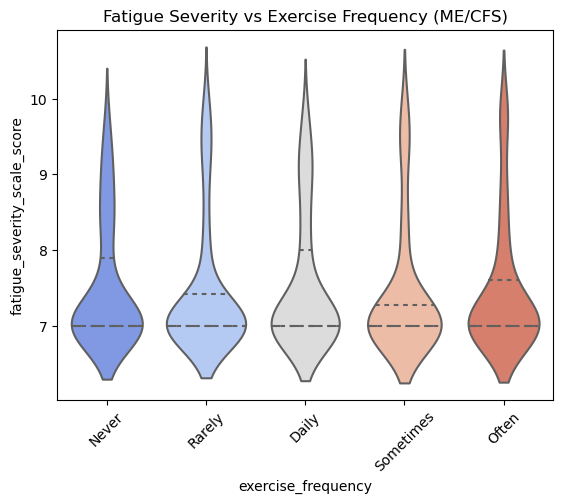

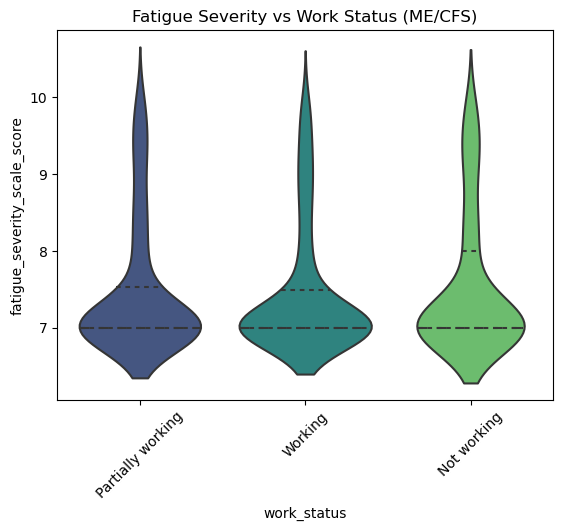

Working: 40.3%
Partially working: 33.2%
Not working: 26.4%
Partially working: 39.9%
Not working: 30.4%
Working: 29.7%
Not working: 40.1%
Partially working: 31.7%
Working: 28.2%


In [6]:
# Filter for ME/CFS only
cfs = df[df['diagnosis'] == 'ME/CFS']

# Fatigue vs Exercise Frequency (ME/CFS)
sns.violinplot(x='exercise_frequency', y='fatigue_severity_scale_score', data=cfs, inner='quartile', palette='coolwarm')
plt.title('Fatigue Severity vs Exercise Frequency (ME/CFS)')
plt.xticks(rotation=45)
plt.show()

# Fatigue vs Work Status (ME/CFS)
sns.violinplot(x='work_status', y='fatigue_severity_scale_score', data=cfs, inner='quartile', palette='viridis')
plt.title('Fatigue Severity vs Work Status (ME/CFS)')
plt.xticks(rotation=45)
plt.show()

work_counts = cfs['work_status'].value_counts(normalize=True) * 100  # percentage

# Print nicely
for status, pct in work_counts.items():
    print(f"{status}: {pct:.1f}%")
    
# Filter Depression
dep = df[df['diagnosis'] == 'Depression']

# Count work status percentages
work_counts_dep = dep['work_status'].value_counts(normalize=True) * 100

# Print nicely
for status, pct in work_counts_dep.items():
    print(f"{status}: {pct:.1f}%")

    
# Filter Depression
depCFS = df[df['diagnosis'] == 'Both']

# Count work status percentages
work_counts_dep = dep['work_status'].value_counts(normalize=True) * 100

# Print nicely
for status, pct in work_counts_dep.items():
    print(f"{status}: {pct:.1f}%")
    
## Finding
# ME is less disabling in terms of work with 40% of people working full time compared to just 29% of people with depression
# When both conditions are present this results in the lowest work level 

In [9]:
# Overall gender vs work status
gender_work = dep.groupby(['gender', 'work_status']).size().unstack(fill_value=0)

# Convert to percentages per gender
gender_work_pct = gender_work.div(gender_work.sum(axis=1), axis=0) * 100
print(gender_work_pct)

# Unexpectedly women with depression work slightly more than men, with females not working = 38% while men not working is 41.5%


work_status  Not working  Partially working    Working
gender                                                
Female         38.613861          30.693069  30.693069
Male           41.584158          32.673267  25.742574


In [8]:
# Looking at work by gender in the cases of ME
# Filter ME/CFS
cfs = df[df['diagnosis'] == 'ME/CFS']

# Gender vs work status counts
cfs_gender_work = cfs.groupby(['gender', 'work_status']).size().unstack(fill_value=0)

# Convert to percentages per gender
cfs_gender_work_pct = cfs_gender_work.div(cfs_gender_work.sum(axis=1), axis=0) * 100
print(cfs_gender_work_pct)

# It seems unlike in the case of depression, men were more likely to either be working full time or not working at all unlike women

work_status  Not working  Partially working    Working
gender                                                
Female         22.580645          36.559140  40.860215
Male           29.857820          30.331754  39.810427


In [12]:
# Filter ME/CFS
depCFS = df[df['diagnosis'] == 'Both']

# Gender vs work status counts
depcfs_gender_work = depCFS.groupby(['gender', 'work_status']).size().unstack(fill_value=0)

# Convert to percentages per gender
depcfs_gender_work_pct = depcfs_gender_work.div(cfs_gender_work.sum(axis=1), axis=0) * 100
print(cfs_gender_work_pct)

# again in people with both conditions men are more disabled than women by about 8%


work_status  Not working  Partially working    Working
gender                                                
Female         22.580645          36.559140  40.860215
Male           29.857820          30.331754  39.810427


                mean       std  min   max    median
diagnosis                                          
Both        5.581538  2.519648  1.1  10.0  5.600000
Depression  5.424742  2.501061  1.0   9.9  5.424742
ME/CFS      5.589817  2.545996  1.0  10.0  5.589817
social_activity_level       High        Low     Medium  Very high   Very low
diagnosis                                                                   
Both                   16.831683  17.326733  20.297030  20.297030  25.247525
Depression             22.693267  18.204489  14.713217  16.458853  27.930175
ME/CFS                 18.891688  23.677582  20.403023  19.899244  17.128463


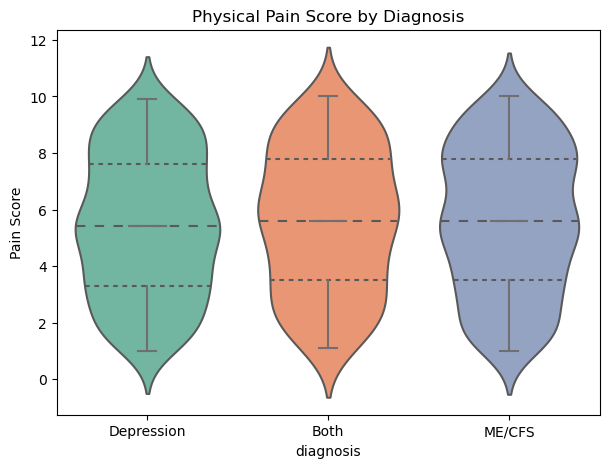

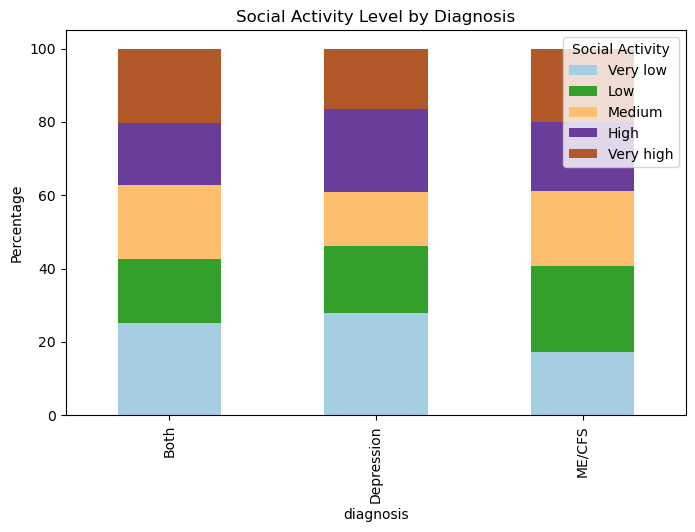

In [23]:
# Group by diagnosis and get mean/std
pain_summary = df.groupby('diagnosis')['physical_pain_score'].agg(['mean','std','min','max','median'])
print(pain_summary)

# reported pain levels are more or less the same in both conditions

social_counts = df.groupby('diagnosis')['social_activity_level'].value_counts(normalize=True).unstack(fill_value=0) * 100
print(social_counts)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.violinplot(x='diagnosis', y='physical_pain_score', data=df, palette='Set2', inner='quartile')
sns.boxplot(x='diagnosis', y='physical_pain_score', data=df, width=0.2, palette='pastel', showcaps=True, boxprops={'facecolor':'None'}, showfliers=True)
plt.title('Physical Pain Score by Diagnosis')
plt.ylabel('Pain Score')
plt.show()

social_counts = df.groupby('diagnosis')['social_activity_level'].value_counts(normalize=True).unstack(fill_value=0) * 100

social_counts[['Very low','Low','Medium','High','Very high']].plot(kind='bar', stacked=True, figsize=(8,5), colormap='Paired')
plt.ylabel('Percentage')
plt.title('Social Activity Level by Diagnosis')
plt.legend(title='Social Activity')
plt.show()

# ME/CFS seems more consistently limited, while depression is more variable socially.
# Both conditions have a notable proportion in the Very Low/Low categories, but the extreme social withdrawal is more pronounced in depression.

           pem_duration_hours                                              \
                        count       mean        std  min   25%        50%   
diagnosis                                                                   
Depression              401.0  22.904393  13.514017  0.0  12.0  22.904393   
ME/CFS                  397.0  23.378866  13.679531  0.0  12.0  23.378866   

                       fatigue_severity_scale_score                           \
             75%   max                        count      mean       std  min   
diagnosis                                                                      
Depression  34.0  47.0                        401.0  4.813995  2.582021  0.0   
ME/CFS      35.0  47.0                        397.0  7.489896  0.861216  7.0   

                                 
            25%  50%  75%   max  
diagnosis                        
Depression  2.5  5.1  7.2   8.0  
ME/CFS      7.0  7.0  7.6  10.0  


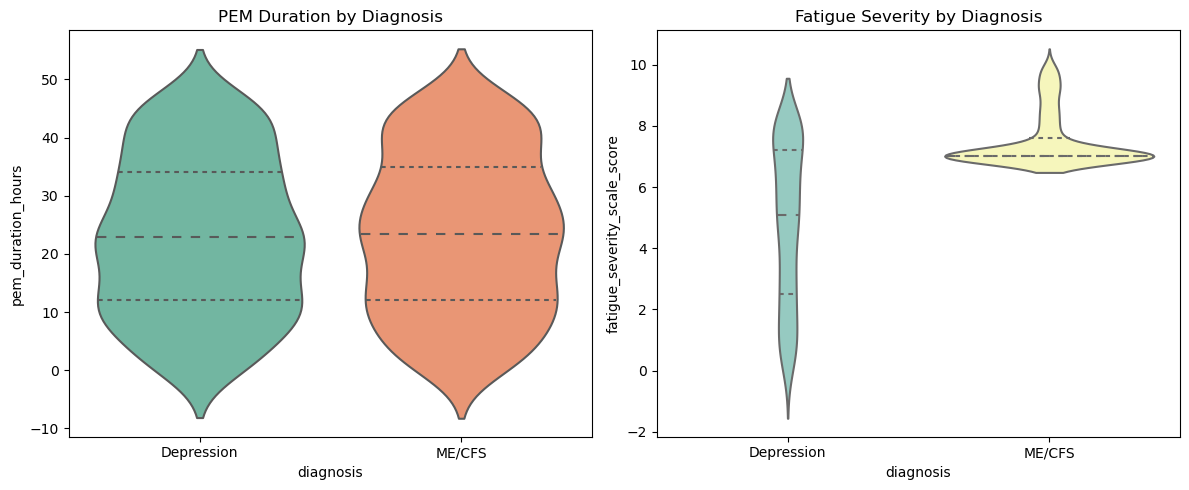

pem_cat     Very High      High    Medium       Low
diagnosis                                          
Depression   0.454780  0.294574  0.160207  0.090439
ME/CFS       0.463918  0.286082  0.146907  0.103093


C:\Users\user\AppData\Local\Temp\ipykernel_7608\1471626967.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['pem_cat'] = pd.cut(df_filtered['pem_duration_hours'], bins=bins, labels=labels)


In [20]:
# Filter out "Both" diagnosis
df_filtered = df[df['diagnosis'] != 'Both']

# Summary stats
pem_fatigue_summary = df_filtered.groupby('diagnosis')[['pem_duration_hours', 'fatigue_severity_scale_score']].describe()
print(pem_fatigue_summary)

# Visualization: side-by-side violin plots
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.violinplot(x='diagnosis', y='pem_duration_hours', data=df_filtered, palette='Set2', inner='quartile')
plt.title('PEM Duration by Diagnosis')

plt.subplot(1,2,2)
sns.violinplot(x='diagnosis', y='fatigue_severity_scale_score', data=df_filtered, palette='Set3', inner='quartile')
plt.title('Fatigue Severity by Diagnosis')

plt.tight_layout()
plt.show()

# The standard deviation is HUGE in pem duration hours for both conditions so we can't tell much from that
bins = [0, 6, 12, 24, df_filtered['pem_duration_hours'].max()]
labels = ['Low', 'Medium', 'High', 'Very High']
df_filtered['pem_cat'] = pd.cut(df_filtered['pem_duration_hours'], bins=bins, labels=labels)
pem_counts = df_filtered.groupby('diagnosis')['pem_cat'].value_counts(normalize=True).unstack()
print(pem_counts)
# PEM is noisy in this dataset and isn't really accurate

# OVERALL the biggest difference between both diagnostics is the fatigue reported by ME patients